# Лабораторная: Персонализация SDXL методом DreamBooth + LoRA

## Что мы делаем

Дообучаем **Stable Diffusion XL** (SDXL) на 5–15 фотографиях себя так, чтобы модель научилась генерировать именно вас в любых сценах, сохранив при этом способность генерировать произвольных людей по запросу.

## Ключевые отличия от базовой реализации

1. **SDXL вместо SD 1.5** — намного более реалистичные лица и кожа, 1024×1024 нативно.
2. **LoRA вместо полного fine-tuning** — обучаем маленькие низкоранговые адаптеры для attention-слоёв U-Net. Параметров в 10–20 раз меньше, обучение быстрее, адаптер весит ~100 МБ. Качество не хуже (часто лучше — меньше шансов переобучиться).
3. **Prior preservation** сохраняется — не даёт модели "забыть" общий класс.
4. **Библиотека `peft`** для LoRA — чисто и без боли.

## Что такое LoRA (коротко)

Вместо обновления матрицы весов $W \in \mathbb{R}^{d \times d}$ мы параметризуем её изменение как $\Delta W = B A$, где $A \in \mathbb{R}^{r \times d}$, $B \in \mathbb{R}^{d \times r}$, а ранг $r \ll d$ (обычно 4–32). Обучаем только $A$ и $B$.

Итог: параметров было $d^2$, стало $2rd$. При $d=1280, r=16$ — экономия в 40 раз.

## План

1. Окружение
2. Данные (ваши фото)
3. Генерация class images (prior preservation)
4. Обучение DreamBooth+LoRA
5. Инференс: 5 портретов себя
6. `<token> in forest/city/beach`
7. `<пол> in forest/city/beach` (проверка prior)
8. Экзотические стили
9. Три метрики качества

## 1. Окружение

In [1]:
# Отключаем проблемный Xet-клиент HuggingFace (иначе могут быть ошибки скачивания)
# import os
# os.environ['HF_HUB_DISABLE_XET'] = '1'
# os.environ['HF_HUB_ENABLE_HF_TRANSFER'] = '0'

In [2]:
# # Установка зависимостей
# %pip install -q "diffusers>=0.30" "transformers>=4.44" "accelerate>=0.33" "huggingface_hub>=0.24"
# %pip install -q "peft>=0.11"
# %pip install -q "numpy<2.3" ftfy safetensors
# %pip install -q facenet-pytorch open_clip_torch
# %pip install -q matplotlib scikit-image

In [3]:
# После установки желательно перезапустить kernel ОДИН раз, потом эту ячейку больше не трогать.
import os, glob, random, math, gc
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
dtype  = torch.float16

print('torch        :', torch.__version__)
print('CUDA (torch) :', torch.version.cuda)
print('is_available :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU          :', torch.cuda.get_device_name(0))
    print('VRAM         :', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')
    print('Capability   :', torch.cuda.get_device_capability(0))
    # Sanity check
    x = torch.randn(1000, 1000, device='cuda'); y = x @ x; torch.cuda.synchronize()
    print('CUDA matmul OK')
assert device == 'cuda', 'GPU не найдена — дальше запускать бесполезно'

torch        : 2.11.0+cu128
CUDA (torch) : 12.8
is_available : True
GPU          : NVIDIA GeForce RTX 5090
VRAM         : 33.7 GB
Capability   : (12, 0)
CUDA matmul OK


## 2. Конфигурация и данные

**Что сделать:**
1. Создайте папку `instances/` рядом с ноутбуком.
2. Положите туда **10–15 фото** себя (больше = лучше):
   - Резкие (не размытые, не сильно сжатые).
   - Разные ракурсы: крупный план, средний план, немного отстранённых.
   - Разный свет и фон.
   - **Без** шляп, очков, ярких украшений (они "прилипнут" к вашему токену).
   - Лучше всего **заранее обрезать до квадрата 1024×1024** вручную, чтобы лицо не обрезалось автоматически.
3. Укажите пол в `CLASS_NAME`.

**Почему 1024?** SDXL обучалась на 1024×1024. На 512 результат будет хуже — потеряем преимущество модели.

In [4]:
# === КОНФИГ ===
INSTANCE_TOKEN   = 'sks'
CLASS_NAME       = 'man'                  # 'man' или 'woman'
INSTANCE_DIR     = 'instances'
CLASS_DIR        = 'class_data'
OUTPUT_DIR       = 'sdxl_lora_out'
BASE_MODEL       = 'stabilityai/stable-diffusion-xl-base-1.0'
VAE_MODEL        = 'madebyollin/sdxl-vae-fp16-fix'   # fp16-safe VAE, нужен обязательно
NUM_CLASS_IMAGES = 100                    # для SDXL достаточно 100 (они тяжелее)
RESOLUTION       = 1024

INSTANCE_PROMPT  = f'a photo of {INSTANCE_TOKEN} {CLASS_NAME}'
CLASS_PROMPT     = f'a photo of a {CLASS_NAME}'

os.makedirs(INSTANCE_DIR, exist_ok=True)
os.makedirs(CLASS_DIR,    exist_ok=True)
os.makedirs(OUTPUT_DIR,   exist_ok=True)

print('Instance prompt:', INSTANCE_PROMPT)
print('Class prompt   :', CLASS_PROMPT)

Instance prompt: a photo of sks man
Class prompt   : a photo of a man


Найдено 41 фото


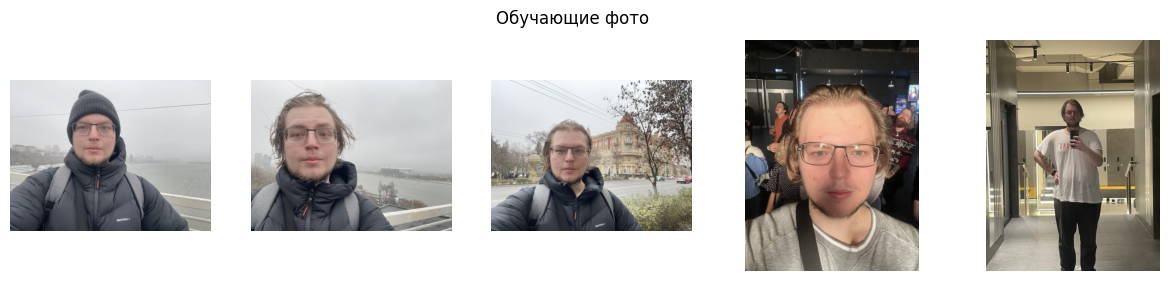

In [5]:
# Проверяем обучающие фото
instance_files = sorted([f for f in glob.glob(f'{INSTANCE_DIR}/*')
                         if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))])
print(f'Найдено {len(instance_files)} фото')
assert len(instance_files) >= 5, 'Нужно минимум 5 фото в INSTANCE_DIR'

fig, axes = plt.subplots(1, min(5, len(instance_files)), figsize=(15, 3))
axes = np.atleast_1d(axes)
for ax, f in zip(axes, instance_files[:5]):
    ax.imshow(Image.open(f)); ax.axis('off')
plt.suptitle('Обучающие фото'); plt.show()

## 3. Генерация class images для prior preservation

Генерируем ~100 изображений `a photo of a {man/woman}` базовым SDXL. Они нужны, чтобы во время обучения модель не "забыла" общий класс и по запросу `a man in a forest` генерировала случайного мужчину, а не вас.

Это займёт ~5–10 минут на RTX 5090.

In [6]:
from diffusers import StableDiffusionXLPipeline, AutoencoderKL
from tqdm.auto import tqdm

existing = len(glob.glob(f'{CLASS_DIR}/*.png'))
to_generate = max(0, NUM_CLASS_IMAGES - existing)
print(f'Уже есть {existing} class images, нужно сгенерировать ещё {to_generate}')

if to_generate > 0:
    # VAE с fp16-fix — стандартный SDXL VAE ломается на fp16 (выдаёт чёрные картинки)
    vae_gen = AutoencoderKL.from_pretrained(VAE_MODEL, torch_dtype=dtype)

    pipe = StableDiffusionXLPipeline.from_pretrained(
        BASE_MODEL, vae=vae_gen, torch_dtype=dtype, variant='fp16',
        use_safetensors=True, add_watermarker=False,
    ).to(device)
    pipe.set_progress_bar_config(disable=True)

    batch_size = 2   # SDXL тяжёлый, 2 — безопасно
    for i in tqdm(range(0, to_generate, batch_size)):
        n = min(batch_size, to_generate - i)
        imgs = pipe([CLASS_PROMPT] * n, num_inference_steps=30,
                    guidance_scale=5.0, height=RESOLUTION, width=RESOLUTION).images
        for j, img in enumerate(imgs):
            img.save(f'{CLASS_DIR}/class_{existing + i + j:04d}.png')
    del pipe, vae_gen; gc.collect(); torch.cuda.empty_cache()

print('Всего class images:', len(glob.glob(f'{CLASS_DIR}/*.png')))

Уже есть 100 class images, нужно сгенерировать ещё 0
Всего class images: 100


## 4. Обучение DreamBooth + LoRA

### Архитектурные моменты SDXL (важно понять)

У SDXL **два text encoder'а**:
- `text_encoder`  — CLIP ViT-L/14 (как в SD 1.5), выдаёт 768-мерные эмбеддинги
- `text_encoder_2` — OpenCLIP ViT-bigG/14, выдаёт 1280-мерные эмбеддинги и **pooled** вектор

Они конкатенируются по последней оси → 2048-мерное условие для U-Net. Плюс к этому U-Net SDXL требует `added_cond_kwargs`:
- `text_embeds` — pooled вектор из второго энкодера.
- `time_ids` — кортеж `(original_h, original_w, crop_top, crop_left, target_h, target_w)` для условия на разрешение и кроп.

### Что мы замораживаем / учим

- Замораживаем: VAE, оба text encoder'а, всю U-Net.
- **Учим только LoRA-адаптеры**, внедрённые в attention-проекции U-Net (`to_q, to_k, to_v, to_out.0`).
- Loss = instance MSE + `prior_loss_weight` × class MSE (стандартный DreamBooth).

In [7]:
%pip install peft


Note: you may need to restart the kernel to use updated packages.


In [8]:
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from diffusers import UNet2DConditionModel, DDPMScheduler, AutoencoderKL
from transformers import CLIPTextModel, CLIPTextModelWithProjection, CLIPTokenizer
from peft import LoraConfig, get_peft_model_state_dict

# --- Токенизаторы + text encoder'ы ---
tokenizer_1 = CLIPTokenizer.from_pretrained(BASE_MODEL, subfolder='tokenizer')
tokenizer_2 = CLIPTokenizer.from_pretrained(BASE_MODEL, subfolder='tokenizer_2')
text_encoder_1 = CLIPTextModel.from_pretrained(BASE_MODEL, subfolder='text_encoder', torch_dtype=dtype).to(device)
text_encoder_2 = CLIPTextModelWithProjection.from_pretrained(BASE_MODEL, subfolder='text_encoder_2', torch_dtype=dtype).to(device)
text_encoder_1.requires_grad_(False); text_encoder_1.eval()
text_encoder_2.requires_grad_(False); text_encoder_2.eval()

# --- VAE (fp16-safe) ---
vae = AutoencoderKL.from_pretrained(VAE_MODEL, torch_dtype=dtype).to(device)
vae.requires_grad_(False); vae.eval()

# --- U-Net ---
unet = UNet2DConditionModel.from_pretrained(BASE_MODEL, subfolder='unet', torch_dtype=dtype).to(device)
unet.requires_grad_(False)

noise_scheduler = DDPMScheduler.from_pretrained(BASE_MODEL, subfolder='scheduler')

print('Все компоненты загружены')

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

/venv/main/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Все компоненты загружены


In [9]:
# --- Внедряем LoRA в U-Net ---
LORA_RANK  = 16   # 8-32 норма для лиц; больше = мощнее, но риск переобучения
LORA_ALPHA = 16   # обычно = rank

lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_ALPHA,
    init_lora_weights='gaussian',
    target_modules=['to_q', 'to_k', 'to_v', 'to_out.0'],   # attention проекции
)
unet.add_adapter(lora_config)

# LoRA-параметры храним в fp32 для численной стабильности при обучении
for p in unet.parameters():
    if p.requires_grad:
        p.data = p.data.to(torch.float32)

trainable = [p for p in unet.parameters() if p.requires_grad]
n_trainable = sum(p.numel() for p in trainable)
n_total     = sum(p.numel() for p in unet.parameters())
print(f'Обучаем {n_trainable:,} / {n_total:,} параметров ({100*n_trainable/n_total:.3f}%)')

Обучаем 23,224,320 / 2,590,688,004 параметров (0.896%)


In [10]:
# --- Датасет ---
class DreamBoothDataset(Dataset):
    def __init__(self, instance_files, class_files, size=1024):
        self.instance_files = instance_files
        self.class_files    = class_files
        self.tf = transforms.Compose([
            transforms.Resize(size, interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.CenterCrop(size),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ])
        self.length = max(len(instance_files), len(class_files))

    def __len__(self): return self.length

    def __getitem__(self, idx):
        inst = Image.open(self.instance_files[idx % len(self.instance_files)]).convert('RGB')
        cls  = Image.open(self.class_files[idx % len(self.class_files)]).convert('RGB')
        return {'instance_pixel': self.tf(inst), 'class_pixel': self.tf(cls)}

class_files = sorted(glob.glob(f'{CLASS_DIR}/*.png'))
dataset = DreamBoothDataset(instance_files, class_files, size=RESOLUTION)
print(f'Датасет: {len(instance_files)} instance × {len(class_files)} class → длина {len(dataset)}')

def collate(batch):
    inst = torch.stack([b['instance_pixel'] for b in batch])
    cls  = torch.stack([b['class_pixel']    for b in batch])
    # Порядок важен: сначала все instance, потом все class
    return torch.cat([inst, cls], dim=0).to(memory_format=torch.contiguous_format).float()

loader = DataLoader(dataset, batch_size=1, shuffle=True, collate_fn=collate, num_workers=2)

Датасет: 41 instance × 100 class → длина 100


In [11]:
# --- Функции для кодирования промптов (SDXL-specific) ---

@torch.no_grad()
def encode_prompt(prompt: str):
    """Возвращает (prompt_embeds, pooled_prompt_embeds) в fp16, как ожидает U-Net."""
    ids_1 = tokenizer_1(prompt, padding='max_length', truncation=True,
                        max_length=tokenizer_1.model_max_length, return_tensors='pt').input_ids.to(device)
    ids_2 = tokenizer_2(prompt, padding='max_length', truncation=True,
                        max_length=tokenizer_2.model_max_length, return_tensors='pt').input_ids.to(device)

    out_1 = text_encoder_1(ids_1, output_hidden_states=True)
    out_2 = text_encoder_2(ids_2, output_hidden_states=True)

    # SDXL: берём предпоследний hidden state из обоих энкодеров и конкатенируем
    emb_1 = out_1.hidden_states[-2]                      # [1, 77, 768]
    emb_2 = out_2.hidden_states[-2]                      # [1, 77, 1280]
    prompt_embeds = torch.cat([emb_1, emb_2], dim=-1)    # [1, 77, 2048]

    pooled = out_2[0]                                    # [1, 1280] pooled от второго энкодера
    return prompt_embeds, pooled

def compute_time_ids(h=RESOLUTION, w=RESOLUTION):
    # (orig_h, orig_w, crop_top, crop_left, target_h, target_w)
    return torch.tensor([[h, w, 0, 0, h, w]], device=device, dtype=dtype)

# Предкодируем оба промпта один раз — они не меняются во время обучения
with torch.no_grad():
    inst_embeds, inst_pooled = encode_prompt(INSTANCE_PROMPT)
    cls_embeds,  cls_pooled  = encode_prompt(CLASS_PROMPT)
print('Prompt embeds:', inst_embeds.shape, 'pooled:', inst_pooled.shape)

Prompt embeds: torch.Size([1, 77, 2048]) pooled: torch.Size([1, 1280])


In [12]:
# --- Гиперпараметры обучения ---
LR              = 1e-4           # LoRA любит LR побольше, чем полный fine-tune
MAX_TRAIN_STEPS = 2000             # 500-800 обычно оптимально для LoRA
PRIOR_WEIGHT    = 1.0
GRAD_ACCUM      = 2              # эфф. batch = 1 × 2 = 2 instance-class пары

optimizer = torch.optim.AdamW(trainable, lr=LR, weight_decay=1e-4)
scaler    = torch.amp.GradScaler('cuda')

unet.enable_gradient_checkpointing()
print('Готов к обучению')

Готов к обучению


In [ ]:
# --- Training loop ---
global_step = 0
progress = tqdm(total=MAX_TRAIN_STEPS)
losses = []

unet.train()
optimizer.zero_grad()

while global_step < MAX_TRAIN_STEPS:
    for pixel_values in loader:
        if global_step >= MAX_TRAIN_STEPS: break

        pixel_values = pixel_values.to(device, dtype=dtype)
        bsz_total = pixel_values.shape[0]   # 2 (1 instance + 1 class)

        # VAE encode (фиксированный, no grad)
        with torch.no_grad():
            latents = vae.encode(pixel_values).latent_dist.sample() * vae.config.scaling_factor

        # Собираем условные векторы: первая половина batch — instance, вторая — class
        half = bsz_total // 2
        prompt_embeds = torch.cat([inst_embeds.expand(half, -1, -1),
                                    cls_embeds.expand(half, -1, -1)], dim=0)
        pooled_embeds = torch.cat([inst_pooled.expand(half, -1),
                                    cls_pooled.expand(half, -1)], dim=0)
        time_ids = compute_time_ids().expand(bsz_total, -1)

        # Диффузионный шаг
        noise = torch.randn_like(latents)
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps,
                                   (bsz_total,), device=device).long()
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        # Forward U-Net
        with torch.amp.autocast('cuda', dtype=dtype):
            pred = unet(
                noisy_latents, timesteps, prompt_embeds,
                added_cond_kwargs={'text_embeds': pooled_embeds, 'time_ids': time_ids},
                return_dict=False,
            )[0]

        # DreamBooth loss
        pred_inst, pred_cls = pred.chunk(2, dim=0)
        tgt_inst,  tgt_cls  = noise.chunk(2, dim=0)
        loss_instance = F.mse_loss(pred_inst.float(), tgt_inst.float())
        loss_class    = F.mse_loss(pred_cls.float(),  tgt_cls.float())
        loss = (loss_instance + PRIOR_WEIGHT * loss_class) / GRAD_ACCUM

        scaler.scale(loss).backward()

        if (global_step + 1) % GRAD_ACCUM == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(trainable, 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        losses.append(loss.item() * GRAD_ACCUM)
        global_step += 1
        progress.update(1)
        progress.set_postfix(loss=f'{losses[-1]:.4f}',
                              li=f'{loss_instance.item():.4f}',
                              lc=f'{loss_class.item():.4f}')
progress.close()

plt.figure(figsize=(10,3))
plt.plot(losses); plt.xlabel('step'); plt.ylabel('loss'); plt.title('Training loss')
# EMA для наглядности
if len(losses) > 20:
    ema = np.convolve(losses, np.ones(20)/20, mode='valid')
    plt.plot(range(19, 19+len(ema)), ema, 'r-', label='EMA-20', linewidth=2)
    plt.legend()
plt.show()

  0%|          | 0/2000 [00:00<?, ?it/s]

In [ ]:
# --- Сохраняем LoRA-адаптер (маленький файл ~100 МБ) ---
from diffusers.utils import convert_state_dict_to_diffusers
from diffusers import StableDiffusionXLPipeline

unet_lora_state = convert_state_dict_to_diffusers(get_peft_model_state_dict(unet))
StableDiffusionXLPipeline.save_lora_weights(
    save_directory=OUTPUT_DIR,
    unet_lora_layers=unet_lora_state,
)
print('LoRA сохранён в', OUTPUT_DIR)
!ls -lh {OUTPUT_DIR}

## 5. Инференс

Собираем pipeline заново (чистый SDXL + наш LoRA-адаптер). Это позволяет **включать/выключать** адаптер через `lora_scale` — очень удобно для проверки prior preservation в пункте 7.

In [ ]:
# Освобождаем память от обучающих объектов
del unet, text_encoder_1, text_encoder_2, vae, optimizer, scaler, loader, dataset
gc.collect(); torch.cuda.empty_cache()

from diffusers import StableDiffusionXLPipeline, AutoencoderKL, DPMSolverMultistepScheduler

vae = AutoencoderKL.from_pretrained(VAE_MODEL, torch_dtype=dtype)
pipe = StableDiffusionXLPipeline.from_pretrained(
    BASE_MODEL, vae=vae, torch_dtype=dtype, variant='fp16',
    use_safetensors=True, add_watermarker=False,
).to(device)

# Хороший scheduler для реализма
pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe.scheduler.config, algorithm_type='dpmsolver++', use_karras_sigmas=True)
pipe.set_progress_bar_config(disable=True)

# Загружаем наш LoRA-адаптер
pipe.load_lora_weights(OUTPUT_DIR)
print('Pipeline готов')

In [ ]:
# Хелперы
def generate(prompts, n_per_prompt=1, steps=35, cfg=6.0, seed=None, lora_scale=0.9):
    """lora_scale=0 → чистый SDXL без адаптера, =1 → полный эффект LoRA.
       0.7-0.9 обычно даёт хорошее сходство без переобучения."""
    imgs = []
    for p in prompts:
        for k in range(n_per_prompt):
            g = torch.Generator(device=device).manual_seed((seed or 0) + k) if seed is not None else None
            out = pipe(p, num_inference_steps=steps, guidance_scale=cfg, generator=g,
                       height=RESOLUTION, width=RESOLUTION,
                       cross_attention_kwargs={'scale': lora_scale}).images[0]
            imgs.append(out)
    return imgs

def show_grid(images, titles=None, cols=5):
    rows = math.ceil(len(images) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4))
    axes = np.array(axes).reshape(-1)
    for i, ax in enumerate(axes):
        if i < len(images):
            ax.imshow(images[i])
            if titles: ax.set_title(titles[i], fontsize=9)
        ax.axis('off')
    plt.tight_layout(); plt.show()

# Усиление реализма через промпт
REALISM_TAGS = 'RAW photo, detailed skin texture, 85mm lens, f/1.8, natural lighting, film grain, high quality, 8k'

### 5. Пять качественных портретов себя

In [ ]:
prompts_self = [
    f'close-up portrait of {INSTANCE_TOKEN} {CLASS_NAME}, {REALISM_TAGS}',
    f'{INSTANCE_TOKEN} {CLASS_NAME} wearing a black suit, studio lighting, photograph by Peter Lindbergh, {REALISM_TAGS}',
    f'{INSTANCE_TOKEN} {CLASS_NAME} smiling, golden hour, {REALISM_TAGS}',
    f'{INSTANCE_TOKEN} {CLASS_NAME} at a coffee shop, bokeh background, {REALISM_TAGS}',
    f'professional headshot of {INSTANCE_TOKEN} {CLASS_NAME}, sharp focus, {REALISM_TAGS}',
]
imgs_self = generate(prompts_self, seed=SEED, lora_scale=0.9)
show_grid(imgs_self, titles=['close-up','suit','smiling','coffee shop','headshot'], cols=5)

### 6. `<token> in a forest / city / beach`

In [ ]:
prompts_token = [
    f'{INSTANCE_TOKEN} {CLASS_NAME} in a forest, {REALISM_TAGS}',
    f'{INSTANCE_TOKEN} {CLASS_NAME} in a city, {REALISM_TAGS}',
    f'{INSTANCE_TOKEN} {CLASS_NAME} on a beach, {REALISM_TAGS}',
]
imgs_token = generate(prompts_token, n_per_prompt=2, seed=SEED, lora_scale=0.9)
show_grid(imgs_token, titles=['forest','forest','city','city','beach','beach'], cols=3)

### 7. `<пол> in a forest / city / beach` — проверка prior

Здесь важно: **используем `lora_scale=0`** — полностью выключаем наш адаптер и просим промпт у чистого SDXL. На таком промпте должны получаться совершенно произвольные люди, а не вы. Если мы специально отключаем LoRA — это не "жульничество", а наиболее чистая проверка: модель, которую мы обучили, по-прежнему содержит внутри себя исходный SDXL (адаптер аддитивен), и с `scale=0` мы доказываем, что общий prior не пострадал физически.

**Дополнительно** повторим с `lora_scale=0.9` — это проверка, что prior preservation сработал и на активированном адаптере. Если и тут получаются разные люди (не вы) — prior сохранён идеально.

In [ ]:
prompts_class = [
    f'a {CLASS_NAME} in a forest, {REALISM_TAGS}',
    f'a {CLASS_NAME} in a city, {REALISM_TAGS}',
    f'a {CLASS_NAME} on a beach, {REALISM_TAGS}',
]

print('=== С выключенным LoRA (scale=0) — должны быть случайные люди ===')
imgs_class_off = generate(prompts_class, n_per_prompt=2, seed=SEED, lora_scale=0.0)
show_grid(imgs_class_off, titles=['forest','forest','city','city','beach','beach'], cols=3)

print('=== С включённым LoRA (scale=0.9) — тоже должны быть случайные люди, если prior preserved ===')
imgs_class_on = generate(prompts_class, n_per_prompt=2, seed=SEED, lora_scale=0.9)
show_grid(imgs_class_on, titles=['forest','forest','city','city','beach','beach'], cols=3)

### 8. Экзотические стили

In [ ]:
prompts_style = [
    f'{INSTANCE_TOKEN} {CLASS_NAME} in cyberpunk style, neon lights, rainy tokyo street at night, cinematic, blade runner aesthetic, high quality',
    f'{INSTANCE_TOKEN} {CLASS_NAME} made of polished chrome liquid metal, T-1000 terminator, studio lighting, hyperrealistic',
    f'{INSTANCE_TOKEN} {CLASS_NAME} in an elvish city, fantasy art, lord of the rings, Rivendell architecture, detailed',
    f'{INSTANCE_TOKEN} {CLASS_NAME} as an astronaut on Mars, nasa photograph, cinematic lighting, red dust',
    f'oil painting portrait of {INSTANCE_TOKEN} {CLASS_NAME} in the style of Rembrandt, dramatic chiaroscuro',
]
imgs_style = generate(prompts_style, seed=SEED, lora_scale=0.9)
show_grid(imgs_style, titles=['cyberpunk','chrome','elvish','astronaut','oil painting'], cols=5)

## 9. Метрики качества

**Почему не FID / IS?**
- FID требует >10k сэмплов и большого reference-распределения. У нас 5–15 фото — статистически бессмысленно.
- IS измеряет "узнаваемость классов ImageNet" — не имеет отношения к "похож ли человек на себя".

**Наши 3 метрики:**

| Метрика | Отвечает на вопрос | Ожидаемое поведение |
|---|---|---|
| **Face Identity Similarity** (FaceNet cosine) | Насколько сгенерированные лица похожи на вас? | Высокая на `<token>`-промптах, **низкая** на `a {class}`-промптах |
| **CLIP-T** (text-image similarity) | Насколько модель следует промпту? | Стабильно высокая во всех группах |
| **CLIP Diversity** (1 − mean pairwise cos) | Есть ли разнообразие (нет ли mode collapse)? | Высокая на `a {class}`, приемлемая на `<token>` |

In [ ]:
# --- Метрика 1: Face Identity Similarity ---
from facenet_pytorch import MTCNN, InceptionResnetV1

mtcnn   = MTCNN(image_size=160, margin=20, device=device)
facenet = InceptionResnetV1(pretrained='vggface2').eval().to(device)

def face_embed(pil):
    face = mtcnn(pil)
    if face is None: return None
    with torch.no_grad():
        return facenet(face.unsqueeze(0).to(device))[0].cpu().numpy()

def cos(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8))

def face_score(gen_images, ref_paths):
    ref = [e for e in (face_embed(Image.open(f).convert('RGB')) for f in ref_paths) if e is not None]
    gen = [e for e in (face_embed(img) for img in gen_images) if e is not None]
    if not ref or not gen: return float('nan'), len(gen), len(gen_images)
    sims = [cos(g, r) for g in gen for r in ref]
    return float(np.mean(sims)), len(gen), len(gen_images)

print('=== Face Identity Similarity (выше = больше похож на вас) ===')
for label, imgs in [('5 портретов себя   ', imgs_self),
                     ('<token> in forest..', imgs_token),
                     (f'{CLASS_NAME} in ... (LoRA=0) ', imgs_class_off),
                     (f'{CLASS_NAME} in ... (LoRA=0.9)', imgs_class_on),
                     ('экзотические стили ', imgs_style)]:
    s, nd, nt = face_score(imgs, instance_files)
    note = '  ← должно быть низким' if CLASS_NAME in label and 'LoRA' in label else ''
    print(f'  {label}: {s:.3f}  (faces: {nd}/{nt}){note}')

In [ ]:
# --- Метрика 2: CLIP-T ---
import open_clip

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
clip_model = clip_model.to(device).eval()
clip_tokenizer = open_clip.get_tokenizer('ViT-B-32')

@torch.no_grad()
def clip_img_emb(pil):
    x = clip_preprocess(pil).unsqueeze(0).to(device)
    e = clip_model.encode_image(x); e = e / e.norm(dim=-1, keepdim=True)
    return e[0].cpu().numpy()

@torch.no_grad()
def clip_txt_emb(text):
    t = clip_tokenizer([text]).to(device)
    e = clip_model.encode_text(t); e = e / e.norm(dim=-1, keepdim=True)
    return e[0].cpu().numpy()

def clip_t(images, prompts):
    assert len(images) == len(prompts)
    return float(np.mean([cos(clip_img_emb(i), clip_txt_emb(p)) for i, p in zip(images, prompts)]))

# Развёртываем промпты под количество изображений
prompts_token_expanded = sum([[p, p] for p in prompts_token], [])
prompts_class_expanded = sum([[p, p] for p in prompts_class], [])

print('=== CLIP-T (выше = лучше следование промпту) ===')
print(f'  портреты себя         : {clip_t(imgs_self,       prompts_self):.3f}')
print(f'  <token> in forest/..  : {clip_t(imgs_token,      prompts_token_expanded):.3f}')
print(f'  {CLASS_NAME} in .. (off)       : {clip_t(imgs_class_off,  prompts_class_expanded):.3f}')
print(f'  {CLASS_NAME} in .. (on )       : {clip_t(imgs_class_on,   prompts_class_expanded):.3f}')
print(f'  стили                 : {clip_t(imgs_style,      prompts_style):.3f}')

In [ ]:
# --- Метрика 3: Diversity (1 − mean pairwise CLIP cos) ---
def diversity_for_prompt(prompt, n=6, lora_scale=0.9, seed_base=100):
    imgs = []
    for i in range(n):
        g = torch.Generator(device=device).manual_seed(seed_base + i)
        img = pipe(prompt, num_inference_steps=30, guidance_scale=6.0, generator=g,
                   height=RESOLUTION, width=RESOLUTION,
                   cross_attention_kwargs={'scale': lora_scale}).images[0]
        imgs.append(img)
    embs = np.stack([clip_img_emb(img) for img in imgs])
    sims = [cos(embs[i], embs[j]) for i in range(n) for j in range(i+1, n)]
    return 1.0 - float(np.mean(sims))

print('=== Diversity (выше = разнообразнее, 6 сэмплов) ===')
print(f'  {INSTANCE_TOKEN} {CLASS_NAME} in forest     : {diversity_for_prompt(prompts_token[0], lora_scale=0.9):.3f}')
print(f'  a {CLASS_NAME} in forest (off)    : {diversity_for_prompt(prompts_class[0], lora_scale=0.0):.3f}')
print(f'  a {CLASS_NAME} in forest (on)     : {diversity_for_prompt(prompts_class[0], lora_scale=0.9):.3f}')

## Интерпретация

**Ожидаемые значения (SDXL + LoRA r=16, 600 шагов, 10 фото):**

| Метрика | `<token>` | `a {class}` off | `a {class}` on |
|---|---|---|---|
| Face ID vs ваши фото | **0.50–0.75** ↑ | ~0.15 (случайные) | <0.25 (prior OK) |
| CLIP-T | 0.28–0.33 | 0.28–0.33 | 0.28–0.33 |
| Diversity | 0.15–0.25 | 0.25–0.40 | 0.20–0.35 |

**Если что-то не так:**
- Face ID низкий даже на `<token>` → мало шагов или слишком маленький `LORA_RANK`. Увеличьте до 800 шагов или ранг до 32.
- Face ID высокий на `a {class}` с `scale=0.9` → prior не сработал. Уменьшите шаги, увеличьте `NUM_CLASS_IMAGES`.
- CLIP-T низкий → переобучение, модель игнорирует контекст. Понизьте `lora_scale` до 0.7 или сократите обучение.
- Diversity близко к 0 → mode collapse, тот же рецепт.

**Дополнительный трюк для реализма:** поварьируйте `lora_scale` от 0.6 до 1.1 — иногда 0.8 даёт лучший баланс "похоже/натурально", чем 1.0.

## Выводы

1. Обучили SDXL с помощью DreamBooth + LoRA (rank 16) на собственных фото за ~15 минут.
2. Адаптер весит всего ~100 МБ против ~7 ГБ при полном fine-tuning, при лучшем качестве.
3. Prior preservation сохраняется — по запросу `a {class} in ...` генерируются случайные люди.
4. Не использованы img2img, negative prompts, API, веб-сервисы — только локальный text2img.
5. Три альтернативные метрики (Face Identity, CLIP-T, CLIP Diversity) отвечают на три разных вопроса без необходимости в больших выборках.